In [1]:
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt

import multiprocessing
pool_size = multiprocessing.cpu_count()

import time
import pandas as pd

import copy


# BA Algorithm

In [2]:
class Bee:
    def __init__(self, n,  m, weights, capacities, constraints, ngh, rng = None):
        """
        Initializes a bee instance.

        :param n: Knapsack dimensionality.
        :param m: Number of items.
        :param weights: Item weights, array of length m.
        :param capacities: Knapsack capacities, array of length n.
        :param constraints: Constraints, array of size nxm.
        :param ngh: Size of neighborhood. 
        :param rng: Random number generator.
        """

        if rng is None:
            rng = np.random.default_rng()
        self.rng = rng

        self.n = n # Knapsack dimensionality

        self.m = m # Number of items

        self.weights = weights # Item weights (length m)

        self.capacities = capacities # Knapsack capacities

        self.constraints = constraints # Constraints, array of size nxm

        self.ngh = ngh # Neighborhood patch size

        self.sol = rng.integers(0, 2, size=self.m).tolist() # Binary solution array: if sol[i] == 1, then item of weights[i] added to knapsack
        
        # Ensure feasibility
        if self.is_feasible(self.sol) is False:
            self.sol = self.repair_overload(sol = self.sol, rng = self.rng)
        

        self.fit = self.evaluate(self.sol) # Calculate the fitness of solution

        self.st = 0 # Keep count of stagnation on the site

    def is_feasible(self, sol):

        """
        Checks wether a solution is feasible. 

        :param sol: Binary array representing solution: if sol[i] == 1, then item of weights[i] added to knapsack.

        :return: True is solution is feasible, False otherwise.
        """

        loads = [sum(sol[j] * self.constraints[i][j] for j in range(self.m)) for i in range(self.n)] # Get loads for each knapsack dimension
        
        feasible = all(loads[i] <= self.capacities[i] for i in range(self.n)) # Check if no capacity constraints are violated

        return feasible
    
    def repair_overload(self, sol, rng = None):
        """
        Repairs an unfeasible solution.

        :param sol: Binary array representing solution: if sol[i] == 1, then item of weights[i] added to knapsack.
        :param rng: Random number generator.

        :return: Repaired solution.
        """

        # Initialize rng if None
        if rng is None:
            rng = np.random.default_rng()

        repaired = sol.copy() # Copy Solution

        loads = [sum(repaired[j] * self.constraints[i][j] for j in range(self.m)) for i in range(self.n)] # Get the loads for each knapsack dimension
            
        
        # Remove items until no capacity constraints are violated
        while any(loads[i] > self.capacities[i] for i in range(self.n)):

            overloaded = [i for i in range(self.n) if loads[i] > self.capacities[i]] # # Get the indices of knapsacks/dimensions that exceed their capacities

            k = rng.choice(overloaded) # Pick a random index

            # Indices of selected items that contribute to resource/dimension k
            selected_items = [j for j in range(self.m) if repaired[j] == 1 and self.constraints[k][j] > 0]

            if not selected_items:
                break  

            item_to_remove = rng.choice(selected_items) # Remove a random item
            repaired[item_to_remove] = 0


            # Update loads
            for i in range(self.n):
                loads[i] = sum(repaired[j] * self.constraints[i][j] for j in range(self.m))
        
        return repaired

       
    def evaluate(self, sol):
        """
        Evaluate the fitness of the solution.

        :param sol:  Binary array representing solution: if sol[i] == 1, then item of weights[i] added to knapsack.

        :return: Fitness/Profit: sum the weights of items added to knapsack.
        """


        total_profit = sum(self.weights[i] * sol[i] for i in range(self.m)) # Add the weights of items added to knapsack; where sol[i] = 1

        return total_profit # return fitness/profit

    def make_neighbor(self, rng = None):
        """
        Create a neighbor by flipping a number of indices. 
        The number of indices is given by the neighborhood patch size.
        If new solution is infeasible, repair it.

        :param rng: Random number generator. Used to pick indices to flip.

        :return: Repaired neighbor solution.
        """

         # Initialize rng if None
        if rng is None:
            rng = np.random.default_rng()


        
        neighbor = self.sol.copy() # Copy current solution into neighbor

        flip_indices = rng.choice(len(self.sol), size=self.ngh, replace=False).tolist() # Pick self.ngh indices to flip


        for idx in flip_indices:
            # Flip chosen indices
            neighbor[idx] = 1 - neighbor[idx]
        
        # Repair solution before returning it
        if self.is_feasible(neighbor) is False:
            neighbor = self.repair_overload(sol = neighbor, rng = self.rng)

        return neighbor
    
    def copy(self):
            """
            Copy Bee object.
            """
            return copy.deepcopy(self)



class BA:
    def __init__(self, n,  m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, rng = None):
        """
        Initializes a BA instance.

        :param n: Knapsack dimensionality.
        :param m: Number of items.
        :param weights: Item weights, array of length m.
        :param capacities: Knapsack capacities, array of length n.
        :param constraints: Constraints, array of size nxm.
        :param ngh: Size of neighborhood. 
        :param ns: Number of scout bees.
        :param nb: Number of best sites to choose per iteration.
        :param ne: Number of elite sites to choose per iteration. (ne < nb)
        :param nre: Number of recruit bees to explore elite sites.
        :param nrb: Number of recruit bees to expore best non-elite sites. (nrb < nre)
        :param stlim: Stagnation limit for site. If stagnation limit is surpassed, the site is replaced with a random one.
        :param rng: Random number generator.
        """


        # Initialize rng if None
        if rng is None:
            rng = np.random.default_rng()
        self.rng = rng

        self.n = n # Number of knapsack dimensions

        self.m = m # Number of items

        self.weights = weights # Items weights (array of size m)

        self.capacities = capacities # Knapsack capacities for each dimension. Array of size n

        self.constraints = constraints # Constraints. Array of size nxm

        self.ngh = ngh # Size of neighborhood patch

        self.ns = ns # Number of scout bees

        self.nb = nb # Number of best sites

        self.ne = ne # Number of elite sites

        self.nre = nre # Number of elite recruits

        self.nrb = nrb # Number of non-elite recruits < nre

        self.stlim = stlim # Stagnation limit for site

        # Initialize ns scout bees
        self.bees = [Bee(n, m, weights, capacities, constraints, ngh, rng) for _ in range(ns)]

        
        self.best_bee_so_far = max(self.bees, key=lambda b: b.fit).copy() # Store the best bee so far

        
        self.best_fit_so_far = self.best_bee_so_far.fit # Store the fitness of the best bee

        

    def run(self, max_iter = 300):
        """
        Main method which runs the BA algorithm.

        :param max_iter: Number of iterations to run the algorithm.


        """


        self.bestfit_history = [] # Store the best fitness per iteration

        self.avgfit_history = [] # Store the average fitness of the population per iteration

        
        for i in range(max_iter):
            
            self.bees.sort(key=lambda b: b.fit, reverse=True) # Sort the bees by fitness in descending order, so the best bee(highest fitness) is first

            best_sites = self.bees[:self.nb] # Select best sites

            elite_sites = best_sites[:self.ne] # Select elite sites from best sites

            non_elite_sites = best_sites[self.ne:] # Select non elite sites from best sites

            # For each elite sites, do a local neighborhood search 
            for i in range(len(elite_sites)):

                improved = False # Checks if there was any improvement on this site 

                for j in range(self.nre): # Loop through  elite recruits for each site

                    recruit = elite_sites[i].make_neighbor(self.rng) # Get neighbor solution

                    # If neighbor solution is better than current solution, replace current solution
                    if elite_sites[i].evaluate(recruit) > elite_sites[i].fit:
                        elite_sites[i].sol = recruit
                        elite_sites[i].fit = elite_sites[i].evaluate(recruit)
                        improved = True 
                
                if improved is True:
                    elite_sites[i].st = 0 # Set st to 0 if site was improved
                else:
                    elite_sites[i].st += 1 # Increase stagnation counter if site was not improved
            
            # Loop through non-elite best sites and do local neighborhood search
            for i in range(len(non_elite_sites)):
                improved = False # Checks if site has been improved

                # Loop through recruits 
                for j in range(self.nrb):
                    recruit = non_elite_sites[i].make_neighbor(self.rng) # Get neighbor solution

                    # Replace current solution if neighbor solution is better 
                    if non_elite_sites[i].evaluate(recruit) > non_elite_sites[i].fit:
                        non_elite_sites[i].sol = recruit
                        non_elite_sites[i].fit = non_elite_sites[i].evaluate(recruit)
                        improved = True

                if improved is True:
                    non_elite_sites[i].st = 0 # Set stagnation counter to 0 if site was improved
                else:
                    non_elite_sites[i].st +=1 # Increase stagnation counter if site was not improved


            # Replace worst sites (different from best sites) with random solutions 
            new_randoms = [Bee(self.n, self.m, self.weights, self.capacities, self.constraints, self.ngh,self.rng) for _ in range(self.ns - self.nb)]
            self.bees = elite_sites + non_elite_sites + new_randoms # New population 


            current_best = max(self.bees, key=lambda b: b.fit) # Get the current best bee
                
            # Check if fitness has been improved
            if current_best.fit > self.best_fit_so_far:
                self.best_fit_so_far = current_best.fit
                self.best_bee_so_far = current_best.copy()


                
            self.bestfit_history.append(self.best_fit_so_far) # Update the history of best fitnesses

            # Update the history of average fitness of entire population
            avg_fitness = np.mean([bee.fit for bee in self.bees]) 
            self.avgfit_history.append(avg_fitness)



        
    

# Helper Functions

In [3]:
# Helper function to for parallel execution

def run_ba(seed, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter = 200):
    """
    Runs a BA instance with a given random seed. 
    Used for parallel execution.

    :param seed: Used to initialize the random number generator. 

    :param n: Knapsack dimensionality. Used to initialize BA instance.
    :param m: Number of items. Used to initialize BA instance.
    :param weights: Item weights, array of length m. Used to initialize BA instance.
    :param capacities: Knapsack capacities, array of length n. Used to initialize BA instance.
    :param constraints: Constraints, array of size nxm. Used to initialize BA instance.
    :param ngh: Size of neighborhood patch. Used to initialize BA instance.
    :param ns: Number of scout bees. Used to initialize BA instance.
    :param nb: Number of best sites to choose per iteration. Used to initialize BA instance.
    :param ne: Number of elite sites to choose per iteration. (ne < nb) Used to initialize BA instance.
    :param nre: Number of recruit bees to explore elite sites. Used to initialize BA instance.
    :param nrb: Number of recruit bees to expore best non-elite sites. (nrb < nre) Used to initialize BA instance.
    :param stlim: Stagnation limit for each site. Used to initialize BA instance.
    :param max_iter: Number of iterations to run the algorithm. Used to initialize main run() method.

    :return: BA instance
    """

    rng =np.random.default_rng(seed) # Initialize Random number generator 

    # Initialize BA instance
    ba = BA(n = n, 
            m = m, 
            weights = weights, 
            capacities = capacities, 
            constraints = constraints, 
            ngh = ngh, 
            ns = ns,
            nb = nb,
            ne = ne,
            nre = nre,
            nrb = nrb, 
            stlim = stlim, 
            rng = rng)
   

    start_time = time.time() # start time counter
    ba.run(max_iter) # Run main method
    end_time = time.time() # end time counter
    
    runtime = end_time - start_time # Get runtime
    
    return ba,runtime # return BA instance and runtime

In [4]:
def read_data(filename):
    """
    Reads a multidimensional knapsack problem data instance.

    :param: Name of the file.

    :return: Knapsack dimensionality, number of items, items weights, capacities of knapsack, constraints.
    """

    with open(filename, "r") as f:
        
        n, m = map(int, f.readline().strip().split()) # Knapsack dimensionality and number of items

        # Items weights
        weights = []
        while len(weights) < m:
            line = f.readline()
            if not line:
                break
            weights.extend(map(int, line.strip().split()))
        

        # Knapsack Capacities
        capacities = []
        while len(capacities) < n:
            line = f.readline()
            if not line:
                break
            capacities.extend(map(int, line.strip().split()))

        # Constraints
        constraints = []
        current_constraint = []
        for line in f:
            line = line.strip()
            if not line:
                continue
            numbers = list(map(int, line.split()))
            for num in numbers:
                current_constraint.append(num)
                if len(current_constraint) == m:
                    constraints.append(current_constraint)
                    current_constraint = []

    return n, m, np.array(weights), np.array(capacities), np.array(constraints) # Return Knapsack dimensionality, number of items, items weights, capacities of knapsack, constraints.




# Algorithm Results

## Instance: WEING1

In [5]:
# Example usage
n, m, weights, capacities, constraints = read_data("Data/WEING1.txt")

print("Knapsack Dimensionality:", n)
print("Number of items:", m)

print("Item Weights:", weights)

print("Knapsack Capacities:", capacities)

print("Constraints:")
for i, c in enumerate(constraints):
    print(f"Constraint {i+1}:", c)



Knapsack Dimensionality: 2
Number of items: 28
Item Weights: [ 1898   440 22507   270 14148  3100  4650 30800   615  4975  1160  4225
   510 11880   479   440   490   330   110   560 24355  2885 11748  4550
   750  3720  1950 10500]
Knapsack Capacities: [600 600]
Constraints:
Constraint 1: [ 45   0  85 150  65  95  30   0 170   0  40  25  20   0   0  25   0   0
  25   0 165   0  85   0   0   0   0 100]
Constraint 2: [ 30  20 125   5  80  25  35  73  12  15  15  40   5  10  10  12  10   9
   0  20  60  40  50  36  49  40  19 150]


Best fitness across all runs: 141278
Corresponding solution: [0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0]


Mean runtime: 0.3925976514816284
Std of runtime: 0.07377746780838865
Min runtime: 0.24112439155578613
Max runtime: 0.437502384185791


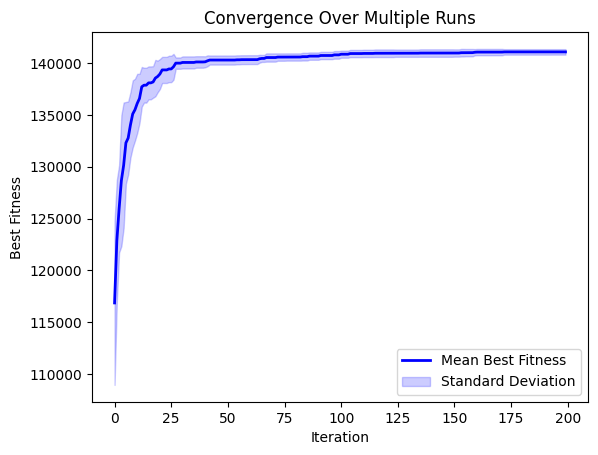

In [6]:
results = [] # Used for parallel execution

all_runs = [] # Results for each run

n_runs = 10

ngh, ns, nb, ne, nre, nrb, stlim, max_iter = 3, 10, 5, 3, 5, 2, 10, 200

# Parallel Execution
with multiprocessing.Pool(processes=pool_size) as pool:
    for run in range(n_runs):
        res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter,))
        results.append(res) # Append results to list

    for result in [res.get() for res in results]:

        run_result = {
            'best_solution': result[0].best_bee_so_far.sol,
            'best_fit':result[0].best_fit_so_far,
            'bestfit_history': result[0].bestfit_history,
            'avgfit_history': result[0].avgfit_history,
            'runtime': result[1]
                                    }
        all_runs.append(run_result)


best_run = max(all_runs, key=lambda x: x['best_fit']) # Find the run with the best fitness
# Extract its solution and fitness
best_solution = best_run['best_solution']
best_fit = best_run['best_fit']

print("Best fitness across all runs:", best_fit)
print("Corresponding solution:", best_solution)


runtimes = [run['runtime'] for run in all_runs]
print("\n\nMean runtime:", np.mean(runtimes))
print("Std of runtime:", np.std(runtimes))
print("Min runtime:", np.min(runtimes))
print("Max runtime:", np.max(runtimes))

# Best fit histories 
bestfit_histories = np.array([run['bestfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanbest_history = bestfit_histories.mean(axis=0)
stdbest_history = bestfit_histories.std(axis=0)

# Average fit histories
avgfit_histories = np.array([run['avgfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanavgfit_history = avgfit_histories.mean(axis=0)
stdavgfit_history = avgfit_histories.std(axis=0)

# Plot best fit histories per iteration
plt.plot(meanbest_history, label='Mean Best Fitness', color='blue', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanbest_history - stdbest_history,
                 meanbest_history + stdbest_history,
                 color='blue', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

In [16]:
print(bestfit_histories.shape)

(10, 400)


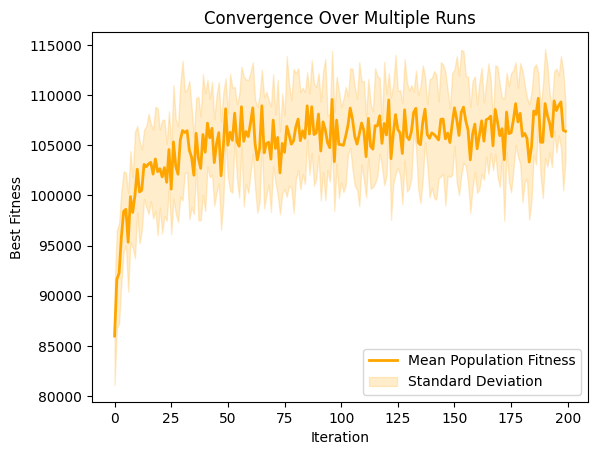

In [7]:
plt.plot(meanavgfit_history, label='Mean Population Fitness', color='orange', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanavgfit_history - stdavgfit_history,
                 meanavgfit_history + stdavgfit_history,
                 color='orange', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

In [8]:
loads = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] 
        
feasible = all(loads[i] <= capacities[i] for i in range(n)) 

if feasible:
    print("Feasible Sol")
else:
    print("Infeasible sol")

Feasible Sol


In [9]:
optimal_value = 141278 # Given in instance data file

total_weight = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] # Weights for each dimension

total_weight = sum(total_weight) # Sum them up

distance_opt = 100 * (optimal_value - best_fit) / optimal_value # Distance from optimal value to best fit found

iterations_to_best_all = [h.index(max(h)) + 1 for h in [run['bestfit_history'] for run in all_runs]]
mean_iter_to_best = np.mean(iterations_to_best_all)
min_iter_to_best = np.min(iterations_to_best_all)
max_iter_to_best = np.max(iterations_to_best_all)

first_value = all_runs[0]['best_fit']  # Best value from the first run
max_value = max(run['best_fit'] for run in all_runs)  # Best value across all runs
improvement_run = 100 * (max_value - first_value) / first_value

improvements = bestfit_histories[:, -1] - bestfit_histories[:, 0]
percent_improvements = (improvements / bestfit_histories[:, 0]) * 100
improvement_first_last_iter = percent_improvements.mean()

iter_improvements = (bestfit_histories[:, 1:] - bestfit_histories[:, :-1]) / (bestfit_histories[:, :-1] ) * 100
mean_iter_improvements_per_run = iter_improvements.mean(axis=1)
improvement_per_iter = mean_iter_improvements_per_run.mean()

stats = {
    'Instance': 'weing1',  
    'n_items': len(weights),
    'Capacity': sum(capacities),
    'Best Value Found': best_fit,
    'Runtime': sum(runtimes),
    'Optimal Value': optimal_value,
    'Weight Used': total_weight,
    'Distance to Optimal': f"{distance_opt:.2f}%",
    'Mean Iter to Best': mean_iter_to_best,
    'Min Iter to Best': min_iter_to_best,
    'Max Iter to Best': max_iter_to_best,
    'Improvement Between Runs': f"{improvement_run:.2f}%",
    'Mean Improvement First to Last Iter': f"{improvement_first_last_iter:.2f}%",
    'Mean Improvement Per Iter': f"{improvement_per_iter:.2f}%"
}

stats_df = pd.DataFrame([stats])
display(stats_df)

,Instance,n_items,Capacity,Best Value Found,Runtime,Optimal Value,Weight Used,Distance to Optimal,Mean Iter to Best,Min Iter to Best,Max Iter to Best,Improvement Between Runs,Mean Improvement First to Last Iter,Mean Improvement Per Iter
0,weing1,28,1200,141278,3.925977,141278,1189,0.00%,128.6,19,194,0.08%,21.23%,0.10%


In [10]:

# Parameter study


ngh_values = [1, 3, 5]
nre_values = [2, 5, 10]
nrb_values = [1, 2, 3, 5]  

valid_combinations = [
    (nre, nrb, ngh)
    for nre in nre_values
    for nrb in nrb_values
    for ngh in ngh_values
    if nrb <= nre
]


results = []
run_info = []
with multiprocessing.Pool(processes=pool_size) as pool:
    for nre, nrb, ngh in valid_combinations:
        run_info.append([nre, nrb, ngh])
        results.append([])
        for run in range(n_runs):
            res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
            results[-1].append(res) # Append results to list

    for i in range(len(results)):
        nre, nrb, ngh = run_info[i]
        run_results = results[i]
        for result in [res.get() for res in run_results]:

            run_result = {
                'nre':nre,
                'nrb': nrb,
                'ngh': ngh,
                'best_solution': result[0].best_bee_so_far.sol,
                'best_fit':result[0].best_fit_so_far,
                'bestfit_history': result[0].bestfit_history,
                'avgfit_history': result[0].avgfit_history,
                'runtime': result[1]
                                        }
            all_runs.append(run_result)
df = pd.DataFrame(all_runs)

df['improvement_first_last_iter'] = df['bestfit_history'].apply(
    lambda hist: (hist[-1] - hist[0]) / hist[0] * 100  
)

df['iter_to_best'] = df['bestfit_history'].apply(
    lambda hist: np.argmax(hist) + 1
)

grouped = df.groupby(['nre', 'nrb', 'ngh']).agg({
    'best_fit': 'max',
    'runtime': 'sum',
    'improvement_first_last_iter': 'mean',
    'iter_to_best': 'mean', 
}).reset_index()
display(grouped)


,nre,nrb,ngh,best_fit,runtime,improvement_first_last_iter,iter_to_best
0,2.0,1.0,1.0,141278,2.183220,24.124624,151.5
1,2.0,1.0,3.0,141168,2.354349,21.787515,115.9
2,2.0,1.0,5.0,140778,2.434256,20.167584,155.6
3,2.0,2.0,1.0,141278,2.372303,24.324201,163.4
4,2.0,2.0,3.0,141278,2.560248,23.434260,146.5
5,2.0,2.0,5.0,141137,2.672664,20.430966,117.4
6,5.0,1.0,1.0,141278,3.502921,24.593010,129.5
7,5.0,1.0,3.0,141278,3.894974,21.859057,110.9
8,5.0,1.0,5.0,141278,3.938389,15.414403,132.9
9,5.0,2.0,1.0,141278,3.728112,25.915923,141.8


## Instance WEING2

In [11]:
# Example usage
n, m, weights, capacities, constraints = read_data("Data/WEING2.txt")

print("Knapsack Dimensionality:", n)
print("Number of items:", m)

print("Item Weights:", weights)

print("Knapsack Capacities:", capacities)

print("Constraints:")
for i, c in enumerate(constraints):
    print(f"Constraint {i+1}:", c)



Knapsack Dimensionality: 2
Number of items: 28
Item Weights: [ 1898   440 22507   270 14148  3100  4650 30800   615  4975  1160  4225
   510 11880   479   440   490   330   110   560 24355  2885 11748  4550
   750  3720  1950 10500]
Knapsack Capacities: [500 500]
Constraints:
Constraint 1: [ 45   0  85 150  65  95  30   0 170   0  40  25  20   0   0  25   0   0
  25   0 165   0  85   0   0   0   0 100]
Constraint 2: [ 30  20 125   5  80  25  35  73  12  15  15  40   5  10  10  12  10   9
   0  20  60  40  50  36  49  40  19 150]


Best fitness across all runs: 130883
Corresponding solution: [0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0]


Mean runtime: 0.4351587533950806
Std of runtime: 0.10506275412887725
Min runtime: 0.3031003475189209
Max runtime: 0.5263195037841797


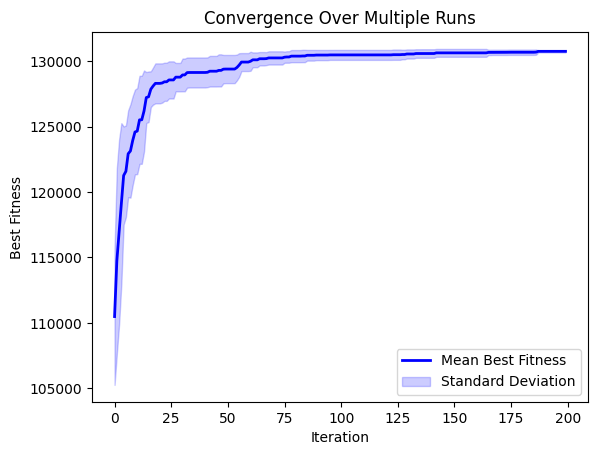

In [12]:
results = [] # Used for parallel execution

all_runs = [] # Results for each run

n_runs = 10

ngh, ns, nb, ne, nre, nrb, stlim, max_iter = 3, 10, 5, 3, 5, 2, 10, 200

# Parallel Execution
with multiprocessing.Pool(processes=pool_size) as pool:
    for run in range(n_runs):
        res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
        results.append(res) # Append results to list

    for result in [res.get() for res in results]:

        run_result = {
            'best_solution': result[0].best_bee_so_far.sol,
            'best_fit':result[0].best_fit_so_far,
            'bestfit_history': result[0].bestfit_history,
            'avgfit_history': result[0].avgfit_history,
            'runtime': result[1]
                                    }
        all_runs.append(run_result)


best_run = max(all_runs, key=lambda x: x['best_fit']) # Find the run with the best fitness
# Extract its solution and fitness
best_solution = best_run['best_solution']
best_fit = best_run['best_fit']

print("Best fitness across all runs:", best_fit)
print("Corresponding solution:", best_solution)


runtimes = [run['runtime'] for run in all_runs]
print("\n\nMean runtime:", np.mean(runtimes))
print("Std of runtime:", np.std(runtimes))
print("Min runtime:", np.min(runtimes))
print("Max runtime:", np.max(runtimes))

# Best fit histories 
bestfit_histories = np.array([run['bestfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanbest_history = bestfit_histories.mean(axis=0)
stdbest_history = bestfit_histories.std(axis=0)

# Average fit histories
avgfit_histories = np.array([run['avgfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanavgfit_history = avgfit_histories.mean(axis=0)
stdavgfit_history = avgfit_histories.std(axis=0)

# Plot best fit histories per iteration
plt.plot(meanbest_history, label='Mean Best Fitness', color='blue', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanbest_history - stdbest_history,
                 meanbest_history + stdbest_history,
                 color='blue', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

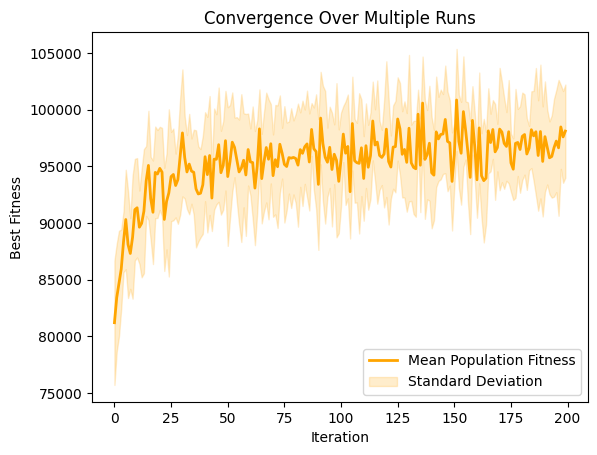

In [13]:
plt.plot(meanavgfit_history, label='Mean Population Fitness', color='orange', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanavgfit_history - stdavgfit_history,
                 meanavgfit_history + stdavgfit_history,
                 color='orange', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

In [14]:
loads = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] 
        
feasible = all(loads[i] <= capacities[i] for i in range(n)) 

if feasible:
    print("Feasible Sol")
else:
    print("Infeasible sol")

Feasible Sol


In [15]:
optimal_value =  130883 # Given in instance data file

total_weight = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] # Weights for each dimension

total_weight = sum(total_weight) # Sum them up

distance_opt = 100 * (optimal_value - best_fit) / optimal_value # Distance from optimal value to best fit found

iterations_to_best_all = [h.index(max(h)) + 1 for h in [run['bestfit_history'] for run in all_runs]]
mean_iter_to_best = np.mean(iterations_to_best_all)
min_iter_to_best = np.min(iterations_to_best_all)
max_iter_to_best = np.max(iterations_to_best_all)

first_value = all_runs[0]['best_fit']  # Best value from the first run
max_value = max(run['best_fit'] for run in all_runs)  # Best value across all runs
improvement_run = 100 * (max_value - first_value) / first_value

improvements = bestfit_histories[:, -1] - bestfit_histories[:, 0]
percent_improvements = (improvements / bestfit_histories[:, 0]) * 100
improvement_first_last_iter = percent_improvements.mean()

iter_improvements = (bestfit_histories[:, 1:] - bestfit_histories[:, :-1]) / (bestfit_histories[:, :-1] ) * 100
mean_iter_improvements_per_run = iter_improvements.mean(axis=1)
improvement_per_iter = mean_iter_improvements_per_run.mean()

stats = {
    'Instance': 'weing2',  
    'n_items': len(weights),
    'Capacity': sum(capacities),
    'Best Value Found': best_fit,
    'Runtime': sum(runtimes),
    'Optimal Value': optimal_value,
    'Weight Used': total_weight,
    'Distance to Optimal': f"{distance_opt:.2f}%",
    'Mean Iter to Best': mean_iter_to_best,
    'Min Iter to Best': min_iter_to_best,
    'Max Iter to Best': max_iter_to_best,
    'Improvement Between Runs': f"{improvement_run:.2f}%",
    'Mean Improvement First to Last Iter': f"{improvement_first_last_iter:.2f}%",
    'Mean Improvement Per Iter': f"{improvement_per_iter:.2f}%"
}

stats_df = pd.DataFrame([stats])
display(stats_df)

,Instance,n_items,Capacity,Best Value Found,Runtime,Optimal Value,Weight Used,Distance to Optimal,Mean Iter to Best,Min Iter to Best,Max Iter to Best,Improvement Between Runs,Mean Improvement First to Last Iter,Mean Improvement Per Iter
0,weing2,28,1000,130883,4.351588,130883,994,0.00%,118.8,31,188,0.12%,18.64%,0.09%


In [16]:

# Parameter study


ngh_values = [1, 3, 5]
nre_values = [2, 5, 10]
nrb_values = [1, 2, 3, 5]  

valid_combinations = [
    (nre, nrb, ngh)
    for nre in nre_values
    for nrb in nrb_values
    for ngh in ngh_values
    if nrb <= nre
]


results = []
run_info = []
with multiprocessing.Pool(processes=pool_size) as pool:
    for nre, nrb, ngh in valid_combinations:
        run_info.append([nre, nrb, ngh])
        results.append([])
        for run in range(n_runs):
            res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
            results[-1].append(res) # Append results to list

    for i in range(len(results)):
        nre, nrb, ngh = run_info[i]
        run_results = results[i]
        for result in [res.get() for res in run_results]:

            run_result = {
                'nre':nre,
                'nrb': nrb,
                'ngh': ngh,
                'best_solution': result[0].best_bee_so_far.sol,
                'best_fit':result[0].best_fit_so_far,
                'bestfit_history': result[0].bestfit_history,
                'avgfit_history': result[0].avgfit_history,
                'runtime': result[1]
                                        }
            all_runs.append(run_result)
df = pd.DataFrame(all_runs)

df['improvement_first_last_iter'] = df['bestfit_history'].apply(
    lambda hist: (hist[-1] - hist[0]) / hist[0] * 100  
)

df['iter_to_best'] = df['bestfit_history'].apply(
    lambda hist: np.argmax(hist) + 1
)

grouped = df.groupby(['nre', 'nrb', 'ngh']).agg({
    'best_fit': 'max',
    'runtime': 'sum',
    'improvement_first_last_iter': 'mean',
    'iter_to_best': 'mean', 
}).reset_index()
display(grouped)


,nre,nrb,ngh,best_fit,runtime,improvement_first_last_iter,iter_to_best
0,2.0,1.0,1.0,130883,2.889182,23.671491,135.0
1,2.0,1.0,3.0,130883,3.102378,24.551543,154.1
2,2.0,1.0,5.0,130563,3.277073,20.033436,119.1
3,2.0,2.0,1.0,130883,3.046346,25.304465,151.7
4,2.0,2.0,3.0,130883,3.369329,23.219288,140.0
5,2.0,2.0,5.0,130103,3.709296,19.538359,85.7
6,5.0,1.0,1.0,130883,4.317889,26.058109,125.9
7,5.0,1.0,3.0,130883,4.787160,17.210008,130.2
8,5.0,1.0,5.0,130563,5.204653,16.971284,120.7
9,5.0,2.0,1.0,130883,4.555927,25.113702,117.4


## SENTO1


In [17]:
# Example usage
n, m, weights, capacities, constraints = read_data("Data/SENTO1.txt")

print("Number of items", m)

print("Knapsack dimensionality", n)

Number of items 60
Knapsack dimensionality 30


Best fitness across all runs: 7670
Corresponding solution: [0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0]


Mean runtime: 18.94111144542694
Std of runtime: 3.5902049482263507
Min runtime: 11.605320692062378
Max runtime: 20.845730781555176


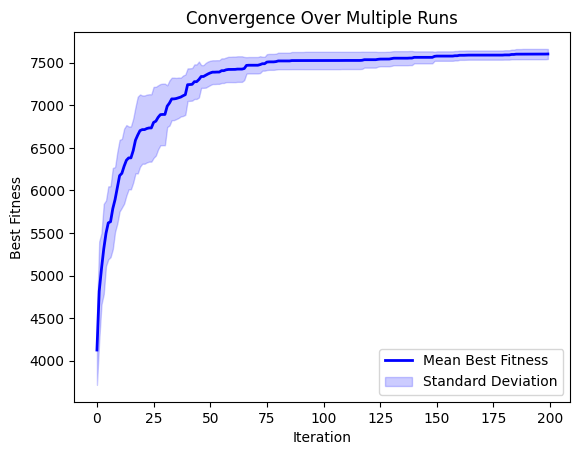

In [18]:
results = [] # Used for parallel execution

all_runs = [] # Results for each run

n_runs = 10

ngh, ns, nb, ne, nre, nrb, stlim, max_iter = 3, 10, 5, 3, 5, 2, 10, 200

# Parallel Execution
with multiprocessing.Pool(processes=pool_size) as pool:
    for run in range(n_runs):
        res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
        results.append(res) # Append results to list

    for result in [res.get() for res in results]:

        run_result = {
            'best_solution': result[0].best_bee_so_far.sol,
            'best_fit':result[0].best_fit_so_far,
            'bestfit_history': result[0].bestfit_history,
            'avgfit_history': result[0].avgfit_history,
            'runtime': result[1]
                                    }
        all_runs.append(run_result)


best_run = max(all_runs, key=lambda x: x['best_fit']) # Find the run with the best fitness
# Extract its solution and fitness
best_solution = best_run['best_solution']
best_fit = best_run['best_fit']

print("Best fitness across all runs:", best_fit)
print("Corresponding solution:", best_solution)


runtimes = [run['runtime'] for run in all_runs]
print("\n\nMean runtime:", np.mean(runtimes))
print("Std of runtime:", np.std(runtimes))
print("Min runtime:", np.min(runtimes))
print("Max runtime:", np.max(runtimes))

# Best fit histories 
bestfit_histories = np.array([run['bestfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanbest_history = bestfit_histories.mean(axis=0)
stdbest_history = bestfit_histories.std(axis=0)

# Average fit histories
avgfit_histories = np.array([run['avgfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanavgfit_history = avgfit_histories.mean(axis=0)
stdavgfit_history = avgfit_histories.std(axis=0)

# Plot best fit histories per iteration
plt.plot(meanbest_history, label='Mean Best Fitness', color='blue', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanbest_history - stdbest_history,
                 meanbest_history + stdbest_history,
                 color='blue', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

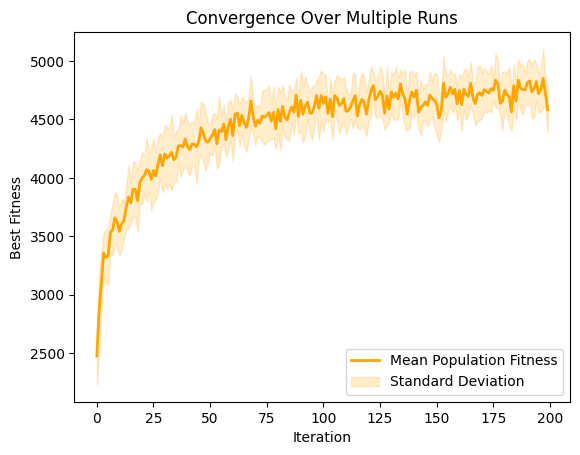

In [19]:
plt.plot(meanavgfit_history, label='Mean Population Fitness', color='orange', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanavgfit_history - stdavgfit_history,
                 meanavgfit_history + stdavgfit_history,
                 color='orange', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

In [20]:
loads = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] 
        
feasible = all(loads[i] <= capacities[i] for i in range(n)) 

if feasible:
    print("Feasible Sol")
else:
    print("Infeasible sol")

Feasible Sol


In [21]:
optimal_value = 7772 # Given in instance data file

total_weight = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] # Weights for each dimension

total_weight = sum(total_weight) # Sum them up

distance_opt = 100 * (optimal_value - best_fit) / optimal_value # Distance from optimal value to best fit found

iterations_to_best_all = [h.index(max(h)) + 1 for h in [run['bestfit_history'] for run in all_runs]]
mean_iter_to_best = np.mean(iterations_to_best_all)
min_iter_to_best = np.min(iterations_to_best_all)
max_iter_to_best = np.max(iterations_to_best_all)

first_value = all_runs[0]['best_fit']  # Best value from the first run
max_value = max(run['best_fit'] for run in all_runs)  # Best value across all runs
improvement_run = 100 * (max_value - first_value) / first_value

improvements = bestfit_histories[:, -1] - bestfit_histories[:, 0]
percent_improvements = (improvements / bestfit_histories[:, 0]) * 100
improvement_first_last_iter = percent_improvements.mean()

iter_improvements = (bestfit_histories[:, 1:] - bestfit_histories[:, :-1]) / (bestfit_histories[:, :-1] ) * 100
mean_iter_improvements_per_run = iter_improvements.mean(axis=1)
improvement_per_iter = mean_iter_improvements_per_run.mean()

stats = {
    'Instance': 'sento1',  
    'n_items': len(weights),
    'Capacity': sum(capacities),
    'Best Value Found': best_fit,
    'Runtime': sum(runtimes),
    'Optimal Value': optimal_value,
    'Weight Used': total_weight,
    'Distance to Optimal': f"{distance_opt:.2f}%",
    'Mean Iter to Best': mean_iter_to_best,
    'Min Iter to Best': min_iter_to_best,
    'Max Iter to Best': max_iter_to_best,
    'Improvement Between Runs': f"{improvement_run:.2f}%",
    'Mean Improvement First to Last Iter': f"{improvement_first_last_iter:.2f}%",
    'Mean Improvement Per Iter': f"{improvement_per_iter:.2f}%"
}

stats_df = pd.DataFrame([stats])
display(stats_df)

,Instance,n_items,Capacity,Best Value Found,Runtime,Optimal Value,Weight Used,Distance to Optimal,Mean Iter to Best,Min Iter to Best,Max Iter to Best,Improvement Between Runs,Mean Improvement First to Last Iter,Mean Improvement Per Iter
0,sento1,60,174000,7670,189.411114,7772,133191,1.31%,153.1,61,200,2.36%,86.08%,0.33%


In [22]:

# Parameter study


ngh_values = [1, 3, 5]
nre_values = [2, 5, 10]
nrb_values = [1, 2, 3, 5]  

valid_combinations = [
    (nre, nrb, ngh)
    for nre in nre_values
    for nrb in nrb_values
    for ngh in ngh_values
    if nrb <= nre
]


results = []
run_info = []
with multiprocessing.Pool(processes=pool_size) as pool:
    for nre, nrb, ngh in valid_combinations:
        run_info.append([nre, nrb, ngh])
        results.append([])
        for run in range(n_runs):
            res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
            results[-1].append(res) # Append results to list

    for i in range(len(results)):
        nre, nrb, ngh = run_info[i]
        run_results = results[i]
        for result in [res.get() for res in run_results]:

            run_result = {
                'nre':nre,
                'nrb': nrb,
                'ngh': ngh,
                'best_solution': result[0].best_bee_so_far.sol,
                'best_fit':result[0].best_fit_so_far,
                'bestfit_history': result[0].bestfit_history,
                'avgfit_history': result[0].avgfit_history,
                'runtime': result[1]
                                        }
            all_runs.append(run_result)
df = pd.DataFrame(all_runs)

df['improvement_first_last_iter'] = df['bestfit_history'].apply(
    lambda hist: (hist[-1] - hist[0]) / hist[0] * 100  
)

df['iter_to_best'] = df['bestfit_history'].apply(
    lambda hist: np.argmax(hist) + 1
)

grouped = df.groupby(['nre', 'nrb', 'ngh']).agg({
    'best_fit': 'max',
    'runtime': 'sum',
    'improvement_first_last_iter': 'mean',
    'iter_to_best': 'mean', 
}).reset_index()
display(grouped)


,nre,nrb,ngh,best_fit,runtime,improvement_first_last_iter,iter_to_best
0,2.0,1.0,1.0,7624,139.789227,96.167304,168.3
1,2.0,1.0,3.0,7564,150.792105,85.816824,169.8
2,2.0,1.0,5.0,7664,162.404490,83.915861,134.1
3,2.0,2.0,1.0,7595,146.262389,89.760618,175.3
4,2.0,2.0,3.0,7590,162.787201,87.808121,152.1
5,2.0,2.0,5.0,7637,177.877960,82.876693,162.4
6,5.0,1.0,1.0,7746,179.558790,85.728753,139.9
7,5.0,1.0,3.0,7667,209.803092,86.234910,146.8
8,5.0,1.0,5.0,7601,228.001598,74.591536,145.7
9,5.0,2.0,1.0,7723,187.469226,89.321195,154.9


## SENTO 2

In [23]:
# Example usage
n, m, weights, capacities, constraints = read_data("Data/SENTO2.txt")

print("Number of items", m)

print("Knapsack dimensionality", n)

Number of items 60
Knapsack dimensionality 30


Best fitness across all runs: 8649
Corresponding solution: [0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0]


Mean runtime: 10.678645968437195
Std of runtime: 2.0236184756000677
Min runtime: 6.5899553298950195
Max runtime: 12.171042203903198


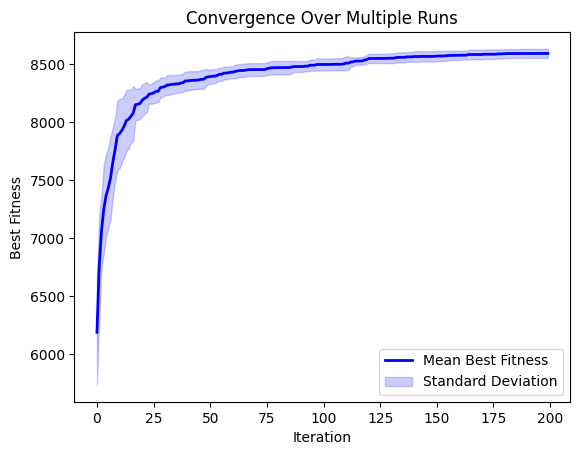

In [24]:
results = [] # Used for parallel execution

all_runs = [] # Results for each run

n_runs = 10

ngh, ns, nb, ne, nre, nrb, stlim, max_iter = 3, 10, 5, 3, 5, 2, 10, 200

# Parallel Execution
with multiprocessing.Pool(processes=pool_size) as pool:
    for run in range(n_runs):
        res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
        results.append(res) # Append results to list

    for result in [res.get() for res in results]:

        run_result = {
            'best_solution': result[0].best_bee_so_far.sol,
            'best_fit':result[0].best_fit_so_far,
            'bestfit_history': result[0].bestfit_history,
            'avgfit_history': result[0].avgfit_history,
            'runtime': result[1]
                                    }
        all_runs.append(run_result)


best_run = max(all_runs, key=lambda x: x['best_fit']) # Find the run with the best fitness
# Extract its solution and fitness
best_solution = best_run['best_solution']
best_fit = best_run['best_fit']

print("Best fitness across all runs:", best_fit)
print("Corresponding solution:", best_solution)


runtimes = [run['runtime'] for run in all_runs]
print("\n\nMean runtime:", np.mean(runtimes))
print("Std of runtime:", np.std(runtimes))
print("Min runtime:", np.min(runtimes))
print("Max runtime:", np.max(runtimes))

# Best fit histories 
bestfit_histories = np.array([run['bestfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanbest_history = bestfit_histories.mean(axis=0)
stdbest_history = bestfit_histories.std(axis=0)

# Average fit histories
avgfit_histories = np.array([run['avgfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanavgfit_history = avgfit_histories.mean(axis=0)
stdavgfit_history = avgfit_histories.std(axis=0)

# Plot best fit histories per iteration
plt.plot(meanbest_history, label='Mean Best Fitness', color='blue', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanbest_history - stdbest_history,
                 meanbest_history + stdbest_history,
                 color='blue', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

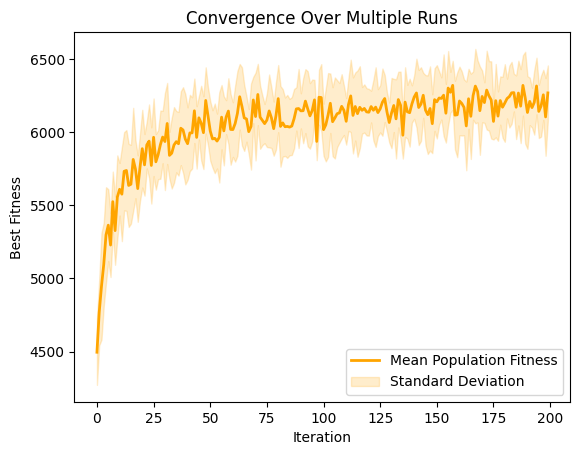

In [25]:
plt.plot(meanavgfit_history, label='Mean Population Fitness', color='orange', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanavgfit_history - stdavgfit_history,
                 meanavgfit_history + stdavgfit_history,
                 color='orange', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

In [26]:
optimal_value = 8722 # Given in instance data file

total_weight = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] # Weights for each dimension

total_weight = sum(total_weight) # Sum them up

distance_opt = 100 * (optimal_value - best_fit) / optimal_value # Distance from optimal value to best fit found

iterations_to_best_all = [h.index(max(h)) + 1 for h in [run['bestfit_history'] for run in all_runs]]
mean_iter_to_best = np.mean(iterations_to_best_all)
min_iter_to_best = np.min(iterations_to_best_all)
max_iter_to_best = np.max(iterations_to_best_all)

first_value = all_runs[0]['best_fit']  # Best value from the first run
max_value = max(run['best_fit'] for run in all_runs)  # Best value across all runs
improvement_run = 100 * (max_value - first_value) / first_value

improvements = bestfit_histories[:, -1] - bestfit_histories[:, 0]
percent_improvements = (improvements / bestfit_histories[:, 0]) * 100
improvement_first_last_iter = percent_improvements.mean()

iter_improvements = (bestfit_histories[:, 1:] - bestfit_histories[:, :-1]) / (bestfit_histories[:, :-1] ) * 100
mean_iter_improvements_per_run = iter_improvements.mean(axis=1)
improvement_per_iter = mean_iter_improvements_per_run.mean()

stats = {
    'Instance': 'sento2',  
    'n_items': len(weights),
    'Capacity': sum(capacities),
    'Best Value Found': best_fit,
    'Runtime': sum(runtimes),
    'Optimal Value': optimal_value,
    'Weight Used': total_weight,
    'Distance to Optimal': f"{distance_opt:.2f}%",
    'Mean Iter to Best': mean_iter_to_best,
    'Min Iter to Best': min_iter_to_best,
    'Max Iter to Best': max_iter_to_best,
    'Improvement Between Runs': f"{improvement_run:.2f}%",
    'Mean Improvement First to Last Iter': f"{improvement_first_last_iter:.2f}%",
    'Mean Improvement Per Iter': f"{improvement_per_iter:.2f}%"
}

stats_df = pd.DataFrame([stats])
display(stats_df)

,Instance,n_items,Capacity,Best Value Found,Runtime,Optimal Value,Weight Used,Distance to Optimal,Mean Iter to Best,Min Iter to Best,Max Iter to Best,Improvement Between Runs,Mean Improvement First to Last Iter,Mean Improvement Per Iter
0,sento2,60,291000,8649,106.78646,8722,230549,0.84%,167.9,141,188,0.15%,39.50%,0.17%


In [27]:
loads = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] 
        
feasible = all(loads[i] <= capacities[i] for i in range(n)) 

if feasible:
    print("Feasible Sol")
else:
    print("Infeasible sol")

Feasible Sol


In [28]:

# Parameter study


ngh_values = [1, 3, 5]
nre_values = [2, 5, 10]
nrb_values = [1, 2, 3, 5]  

valid_combinations = [
    (nre, nrb, ngh)
    for nre in nre_values
    for nrb in nrb_values
    for ngh in ngh_values
    if nrb <= nre
]


results = []
run_info = []
with multiprocessing.Pool(processes=pool_size) as pool:
    for nre, nrb, ngh in valid_combinations:
        run_info.append([nre, nrb, ngh])
        results.append([])
        for run in range(n_runs):
            res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
            results[-1].append(res) # Append results to list

    for i in range(len(results)):
        nre, nrb, ngh = run_info[i]
        run_results = results[i]
        for result in [res.get() for res in run_results]:

            run_result = {
                'nre':nre,
                'nrb': nrb,
                'ngh': ngh,
                'best_solution': result[0].best_bee_so_far.sol,
                'best_fit':result[0].best_fit_so_far,
                'bestfit_history': result[0].bestfit_history,
                'avgfit_history': result[0].avgfit_history,
                'runtime': result[1]
                                        }
            all_runs.append(run_result)
df = pd.DataFrame(all_runs)

df['improvement_first_last_iter'] = df['bestfit_history'].apply(
    lambda hist: (hist[-1] - hist[0]) / hist[0] * 100  
)

df['iter_to_best'] = df['bestfit_history'].apply(
    lambda hist: np.argmax(hist) + 1
)

grouped = df.groupby(['nre', 'nrb', 'ngh']).agg({
    'best_fit': 'max',
    'runtime': 'sum',
    'improvement_first_last_iter': 'mean',
    'iter_to_best': 'mean', 
}).reset_index()
display(grouped)


,nre,nrb,ngh,best_fit,runtime,improvement_first_last_iter,iter_to_best
0,2.0,1.0,1.0,8575,65.687644,38.798615,157.6
1,2.0,1.0,3.0,8555,73.093929,41.671538,157.4
2,2.0,1.0,5.0,8501,76.300835,36.070832,163.1
3,2.0,2.0,1.0,8617,72.582351,41.204073,175.9
4,2.0,2.0,3.0,8636,81.681317,42.128526,156.2
5,2.0,2.0,5.0,8508,87.427943,35.828232,159.2
6,5.0,1.0,1.0,8667,99.617292,38.195513,169.7
7,5.0,1.0,3.0,8698,116.046392,40.239819,142.4
8,5.0,1.0,5.0,8525,119.579957,30.465560,157.4
9,5.0,2.0,1.0,8609,104.545889,36.985596,162.6


## Large 1

In [29]:
## File format is different here

def read_data2(filename):
    """
    Reads a multidimensional knapsack problem data instance.

    :param: Name of the file.

    :return: Knapsack dimensionality, number of items, items weights, capacities of knapsack, constraints.
    """

    with open(filename, "r") as f:

        no_problems  = map(int, f.readline().strip().split())

        m, n, opt = map(int, f.readline().strip().split())# Knapsack dimensionality and number of items

        # Items weights
        weights = []
        while len(weights) < m:
            line = f.readline()
            if not line:
                break
            weights.extend(map(int, line.strip().split()))
        

        

        # Constraints
        constraints = []
        current_row = []
        while len(constraints) < n:  # n rows/dimensions
            line = f.readline()
            if not line:
                break
            nums = list(map(int, line.strip().split()))
            current_row.extend(nums)
            # Once we have m numbers, append as one row
            while len(current_row) >= m:
                constraints.append(current_row[:m])
                current_row = current_row[m:]
        
        # Knapsack Capacities
        capacities = []
        while len(capacities) < n:
            line = f.readline()
            if not line:
                break
            capacities.extend(map(int, line.strip().split()))

    return n, m, np.array(weights), np.array(capacities), np.array(constraints) # Return Knapsack dimensionality, number of items, items weights, capacities of knapsack, constraints.




In [30]:
n, m, weights, capacities, constraints = read_data2("Data/mknapcb8.txt")

print("Number of items:", m)

print("Knapsack dimensionality:", n)

print("Weights shape:", weights.shape)         # (m,)
print("Constraints shape:", constraints.shape) # (n, m)
print("Capacities shape:", capacities.shape)   # (n,)

Number of items: 250
Knapsack dimensionality: 30
Weights shape: (250,)
Constraints shape: (30, 250)
Capacities shape: (30,)


Best fitness across all runs: 50528
Corresponding solution: [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0]


Mean runtime: 177.05311892032623
Std of runtime: 34.93812277383923
Min runtime: 105.9473044872284
Max runtime: 197.3884904384613


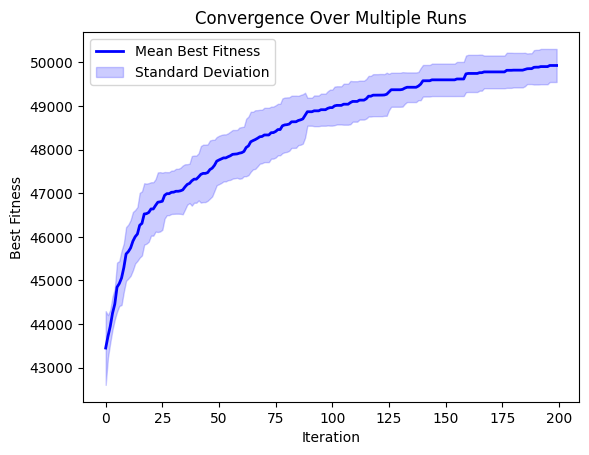

In [31]:
results = [] # Used for parallel execution

all_runs = [] # Results for each run

n_runs = 10

ngh, ns, nb, ne, nre, nrb, stlim, max_iter = 3, 10, 5, 3, 5, 2, 10, 200

# Parallel Execution
with multiprocessing.Pool(processes=pool_size) as pool:
    for run in range(n_runs):
        res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
        results.append(res) # Append results to list

    for result in [res.get() for res in results]:

        run_result = {
            'best_solution': result[0].best_bee_so_far.sol,
            'best_fit':result[0].best_fit_so_far,
            'bestfit_history': result[0].bestfit_history,
            'avgfit_history': result[0].avgfit_history,
            'runtime': result[1]
                                    }
        all_runs.append(run_result)


best_run = max(all_runs, key=lambda x: x['best_fit']) # Find the run with the best fitness
# Extract its solution and fitness
best_solution = best_run['best_solution']
best_fit = best_run['best_fit']

print("Best fitness across all runs:", best_fit)
print("Corresponding solution:", best_solution)


runtimes = [run['runtime'] for run in all_runs]
print("\n\nMean runtime:", np.mean(runtimes))
print("Std of runtime:", np.std(runtimes))
print("Min runtime:", np.min(runtimes))
print("Max runtime:", np.max(runtimes))

# Best fit histories 
bestfit_histories = np.array([run['bestfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanbest_history = bestfit_histories.mean(axis=0)
stdbest_history = bestfit_histories.std(axis=0)

# Average fit histories
avgfit_histories = np.array([run['avgfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanavgfit_history = avgfit_histories.mean(axis=0)
stdavgfit_history = avgfit_histories.std(axis=0)

# Plot best fit histories per iteration
plt.plot(meanbest_history, label='Mean Best Fitness', color='blue', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanbest_history - stdbest_history,
                 meanbest_history + stdbest_history,
                 color='blue', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

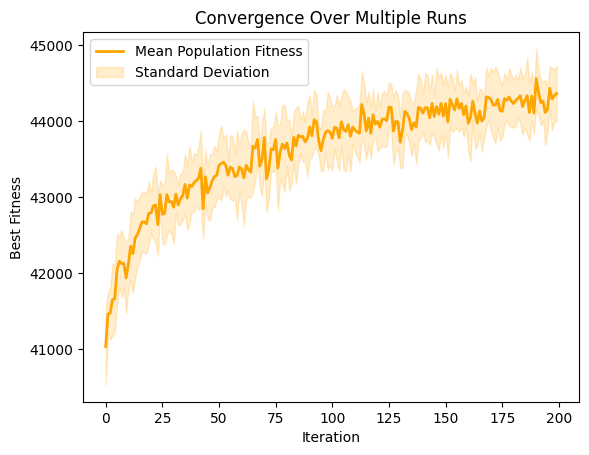

In [32]:
plt.plot(meanavgfit_history, label='Mean Population Fitness', color='orange', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanavgfit_history - stdavgfit_history,
                 meanavgfit_history + stdavgfit_history,
                 color='orange', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

In [33]:
loads = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] 
        
feasible = all(loads[i] <= capacities[i] for i in range(n)) 

if feasible:
    print("Feasible Sol")
else:
    print("Infeasible sol")

Feasible Sol


In [34]:
optimal_value = 56693 # Given in instance data file

total_weight = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] # Weights for each dimension

total_weight = sum(total_weight) # Sum them up

distance_opt = 100 * (optimal_value - best_fit) / optimal_value # Distance from optimal value to best fit found

iterations_to_best_all = [h.index(max(h)) + 1 for h in [run['bestfit_history'] for run in all_runs]]
mean_iter_to_best = np.mean(iterations_to_best_all)
min_iter_to_best = np.min(iterations_to_best_all)
max_iter_to_best = np.max(iterations_to_best_all)

first_value = all_runs[0]['best_fit']  # Best value from the first run
max_value = max(run['best_fit'] for run in all_runs)  # Best value across all runs
improvement_run = 100 * (max_value - first_value) / first_value

improvements = bestfit_histories[:, -1] - bestfit_histories[:, 0]
percent_improvements = (improvements / bestfit_histories[:, 0]) * 100
improvement_first_last_iter = percent_improvements.mean()

iter_improvements = (bestfit_histories[:, 1:] - bestfit_histories[:, :-1]) / (bestfit_histories[:, :-1] ) * 100
mean_iter_improvements_per_run = iter_improvements.mean(axis=1)
improvement_per_iter = mean_iter_improvements_per_run.mean()

stats = {
    'Instance': '30.250-00',  
    'n_items': len(weights),
    'Capacity': sum(capacities),
    'Best Value Found': best_fit,
    'Runtime': sum(runtimes),
    'Optimal Value': optimal_value,
    'Weight Used': total_weight,
    'Distance to Optimal': f"{distance_opt:.2f}%",
    'Mean Iter to Best': mean_iter_to_best,
    'Min Iter to Best': min_iter_to_best,
    'Max Iter to Best': max_iter_to_best,
    'Improvement Between Runs': f"{improvement_run:.2f}%",
    'Mean Improvement First to Last Iter': f"{improvement_first_last_iter:.2f}%",
    'Mean Improvement Per Iter': f"{improvement_per_iter:.2f}%"
}

stats_df = pd.DataFrame([stats])
display(stats_df)

,Instance,n_items,Capacity,Best Value Found,Runtime,Optimal Value,Weight Used,Distance to Optimal,Mean Iter to Best,Min Iter to Best,Max Iter to Best,Improvement Between Runs,Mean Improvement First to Last Iter,Mean Improvement Per Iter
0,30.250-00,250,935330,50528,1770.531189,56693,890693,10.87%,175.4,117,197,2.68%,14.95%,0.07%


In [36]:

# Parameter study


ngh_values = [1, 3, 5]
nre_values = [2, 5, 10]
nrb_values = [1, 2, 3, 5]  

valid_combinations = [
    (nre, nrb, ngh)
    for nre in nre_values
    for nrb in nrb_values
    for ngh in ngh_values
    if nrb <= nre
]


results = []
run_info = []
with multiprocessing.Pool(processes=pool_size) as pool:
    for nre, nrb, ngh in valid_combinations:
        run_info.append([nre, nrb, ngh])
        results.append([])
        for run in range(n_runs):
            res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
            results[-1].append(res) # Append results to list

    for i in range(len(results)):
        nre, nrb, ngh = run_info[i]
        run_results = results[i]
        for result in [res.get() for res in run_results]:

            run_result = {
                'nre':nre,
                'nrb': nrb,
                'ngh': ngh,
                'best_solution': result[0].best_bee_so_far.sol,
                'best_fit':result[0].best_fit_so_far,
                'bestfit_history': result[0].bestfit_history,
                'avgfit_history': result[0].avgfit_history,
                'runtime': result[1]
                                        }
            all_runs.append(run_result)
df = pd.DataFrame(all_runs)

df['improvement_first_last_iter'] = df['bestfit_history'].apply(
    lambda hist: (hist[-1] - hist[0]) / hist[0] * 100  
)

df['iter_to_best'] = df['bestfit_history'].apply(
    lambda hist: np.argmax(hist) + 1
)

grouped = df.groupby(['nre', 'nrb', 'ngh']).agg({
    'best_fit': 'max',
    'runtime': 'sum',
    'improvement_first_last_iter': 'mean',
    'iter_to_best': 'mean', 
}).reset_index()
display(grouped)


,nre,nrb,ngh,best_fit,runtime,improvement_first_last_iter,iter_to_best
0,2.0,1.0,1.0,50611,3491.912655,14.178064,173.1
1,2.0,1.0,3.0,50109,3589.030079,13.548450,173.0
2,2.0,1.0,5.0,49943,3730.441558,12.254146,152.2
3,2.0,2.0,1.0,49820,3536.157874,14.046709,167.0
4,2.0,2.0,3.0,49576,3694.524667,13.015775,174.7
5,2.0,2.0,5.0,49711,3815.908066,12.286389,182.8
6,5.0,1.0,1.0,51742,3747.823152,17.305897,185.9
7,5.0,1.0,3.0,50774,4071.253928,14.775092,171.9
8,5.0,1.0,5.0,50383,4241.360331,13.358047,145.4
9,5.0,2.0,1.0,51695,1894.170025,17.833063,185.0


## Large 2


In [37]:
n, m, weights, capacities, constraints = read_data2("Data/mknapcb9.txt")

print("Number of items:", m)

print("Knapsack dimensionality:", n)

print("Weights shape:", weights.shape)         # (m,)
print("Constraints shape:", constraints.shape) # (n, m)
print("Capacities shape:", capacities.shape)   # (n,)

Number of items: 500
Knapsack dimensionality: 30
Weights shape: (500,)
Constraints shape: (30, 500)
Capacities shape: (30,)


Best fitness across all runs: 101063
Corresponding solution: [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

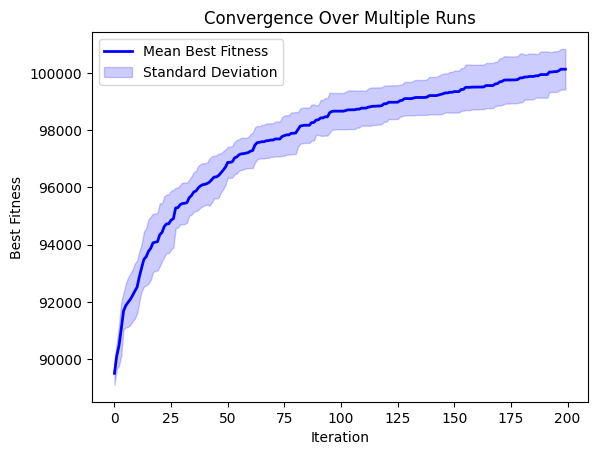

In [38]:
results = [] # Used for parallel execution

all_runs = [] # Results for each run

n_runs = 10

ngh, ns, nb, ne, nre, nrb, stlim, max_iter = 3, 10, 5, 3, 5, 2, 10, 200

# Parallel Execution
with multiprocessing.Pool(processes=pool_size) as pool:
    for run in range(n_runs):
        res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
        results.append(res) # Append results to list

    for result in [res.get() for res in results]:

        run_result = {
            'best_solution': result[0].best_bee_so_far.sol,
            'best_fit':result[0].best_fit_so_far,
            'bestfit_history': result[0].bestfit_history,
            'avgfit_history': result[0].avgfit_history,
            'runtime': result[1]
                                    }
        all_runs.append(run_result)


best_run = max(all_runs, key=lambda x: x['best_fit']) # Find the run with the best fitness
# Extract its solution and fitness
best_solution = best_run['best_solution']
best_fit = best_run['best_fit']

print("Best fitness across all runs:", best_fit)
print("Corresponding solution:", best_solution)


runtimes = [run['runtime'] for run in all_runs]
print("\n\nMean runtime:", np.mean(runtimes))
print("Std of runtime:", np.std(runtimes))
print("Min runtime:", np.min(runtimes))
print("Max runtime:", np.max(runtimes))

# Best fit histories 
bestfit_histories = np.array([run['bestfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanbest_history = bestfit_histories.mean(axis=0)
stdbest_history = bestfit_histories.std(axis=0)

# Average fit histories
avgfit_histories = np.array([run['avgfit_history'] for run in all_runs])
# Compute mean and standard deviation across runs
meanavgfit_history = avgfit_histories.mean(axis=0)
stdavgfit_history = avgfit_histories.std(axis=0)

# Plot best fit histories per iteration
plt.plot(meanbest_history, label='Mean Best Fitness', color='blue', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanbest_history - stdbest_history,
                 meanbest_history + stdbest_history,
                 color='blue', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

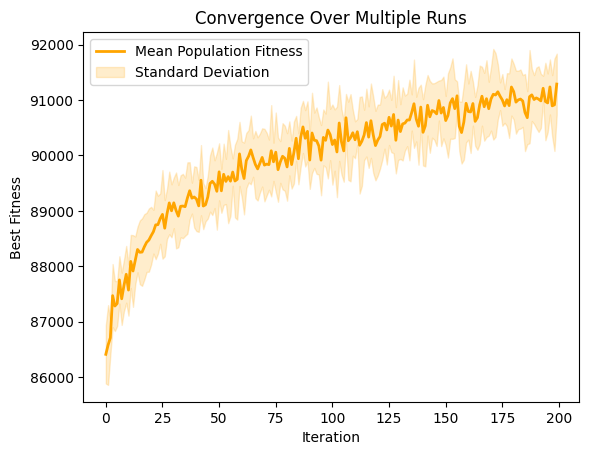

In [39]:
plt.plot(meanavgfit_history, label='Mean Population Fitness', color='orange', linewidth=2)
plt.fill_between(range(bestfit_histories.shape[1]),
                 meanavgfit_history - stdavgfit_history,
                 meanavgfit_history + stdavgfit_history,
                 color='orange', alpha=0.2, label='Standard Deviation')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('Convergence Over Multiple Runs')
plt.legend()
plt.show()

In [40]:
loads = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] 
        
feasible = all(loads[i] <= capacities[i] for i in range(n)) 

if feasible:
    print("Feasible Sol")
else:
    print("Infeasible sol")

Feasible Sol


In [41]:
optimal_value = 115868 # Given in instance data file

total_weight = [sum(best_solution[j] * constraints[i][j] for j in range(m)) for i in range(n)] # Weights for each dimension

total_weight = sum(total_weight) # Sum them up

distance_opt = 100 * (optimal_value - best_fit) / optimal_value # Distance from optimal value to best fit found

iterations_to_best_all = [h.index(max(h)) + 1 for h in [run['bestfit_history'] for run in all_runs]]
mean_iter_to_best = np.mean(iterations_to_best_all)
min_iter_to_best = np.min(iterations_to_best_all)
max_iter_to_best = np.max(iterations_to_best_all)

first_value = all_runs[0]['best_fit']  # Best value from the first run
max_value = max(run['best_fit'] for run in all_runs)  # Best value across all runs
improvement_run = 100 * (max_value - first_value) / first_value

improvements = bestfit_histories[:, -1] - bestfit_histories[:, 0]
percent_improvements = (improvements / bestfit_histories[:, 0]) * 100
improvement_first_last_iter = percent_improvements.mean()

iter_improvements = (bestfit_histories[:, 1:] - bestfit_histories[:, :-1]) / (bestfit_histories[:, :-1] ) * 100
mean_iter_improvements_per_run = iter_improvements.mean(axis=1)
improvement_per_iter = mean_iter_improvements_per_run.mean()

stats = {
    'Instance': '30.500-00',  
    'n_items': len(weights),
    'Capacity': sum(capacities),
    'Best Value Found': best_fit,
    'Runtime': sum(runtimes),
    'Optimal Value': optimal_value,
    'Weight Used': total_weight,
    'Distance to Optimal': f"{distance_opt:.2f}%",
    'Mean Iter to Best': mean_iter_to_best,
    'Min Iter to Best': min_iter_to_best,
    'Max Iter to Best': max_iter_to_best,
    'Improvement Between Runs': f"{improvement_run:.2f}%",
    'Mean Improvement First to Last Iter': f"{improvement_first_last_iter:.2f}%",
    'Mean Improvement Per Iter': f"{improvement_per_iter:.2f}%"
}

stats_df = pd.DataFrame([stats])
display(stats_df)

,Instance,n_items,Capacity,Best Value Found,Runtime,Optimal Value,Weight Used,Distance to Optimal,Mean Iter to Best,Min Iter to Best,Max Iter to Best,Improvement Between Runs,Mean Improvement First to Last Iter,Mean Improvement Per Iter
0,30.500-00,500,1870374,101063,5981.602615,115868,1804228,12.78%,173.1,127,198,0.00%,11.86%,0.06%


In [42]:

# Parameter study


ngh_values = [1, 3, 5]
nre_values = [2, 5, 10]
nrb_values = [1, 2, 3, 5]  

valid_combinations = [
    (nre, nrb, ngh)
    for nre in nre_values
    for nrb in nrb_values
    for ngh in ngh_values
    if nrb <= nre
]


results = []
run_info = []
with multiprocessing.Pool(processes=pool_size) as pool:
    for nre, nrb, ngh in valid_combinations:
        run_info.append([nre, nrb, ngh])
        results.append([])
        for run in range(n_runs):
            res = pool.apply_async(run_ba, (run, n, m, weights, capacities, constraints, ngh, ns, nb, ne, nre, nrb, stlim, max_iter))
            results[-1].append(res) # Append results to list

    for i in range(len(results)):
        nre, nrb, ngh = run_info[i]
        run_results = results[i]
        for result in [res.get() for res in run_results]:

            run_result = {
                'nre':nre,
                'nrb': nrb,
                'ngh': ngh,
                'best_solution': result[0].best_bee_so_far.sol,
                'best_fit':result[0].best_fit_so_far,
                'bestfit_history': result[0].bestfit_history,
                'avgfit_history': result[0].avgfit_history,
                'runtime': result[1]
                                        }
            all_runs.append(run_result)
df = pd.DataFrame(all_runs)

df['improvement_first_last_iter'] = df['bestfit_history'].apply(
    lambda hist: (hist[-1] - hist[0]) / hist[0] * 100  
)

df['iter_to_best'] = df['bestfit_history'].apply(
    lambda hist: np.argmax(hist) + 1
)

grouped = df.groupby(['nre', 'nrb', 'ngh']).agg({
    'best_fit': 'max',
    'runtime': 'sum',
    'improvement_first_last_iter': 'mean',
    'iter_to_best': 'mean', 
}).reset_index()
display(grouped)


,nre,nrb,ngh,best_fit,runtime,improvement_first_last_iter,iter_to_best
0,2.0,1.0,1.0,99302,7301.320127,9.760352,189.4
1,2.0,1.0,3.0,98636,6810.494224,9.502607,163.3
2,2.0,1.0,5.0,99360,7127.718960,9.849403,171.6
3,2.0,2.0,1.0,100941,7196.219623,10.125294,177.4
4,2.0,2.0,3.0,99498,7601.894778,9.956396,175.4
5,2.0,2.0,5.0,98296,7105.852356,9.015166,172.1
6,5.0,1.0,1.0,102282,7446.635209,12.688273,182.4
7,5.0,1.0,3.0,101066,7758.872602,11.547469,188.6
8,5.0,1.0,5.0,101005,7641.523365,10.080512,176.1
9,5.0,2.0,1.0,104144,7923.851583,14.090389,189.9
